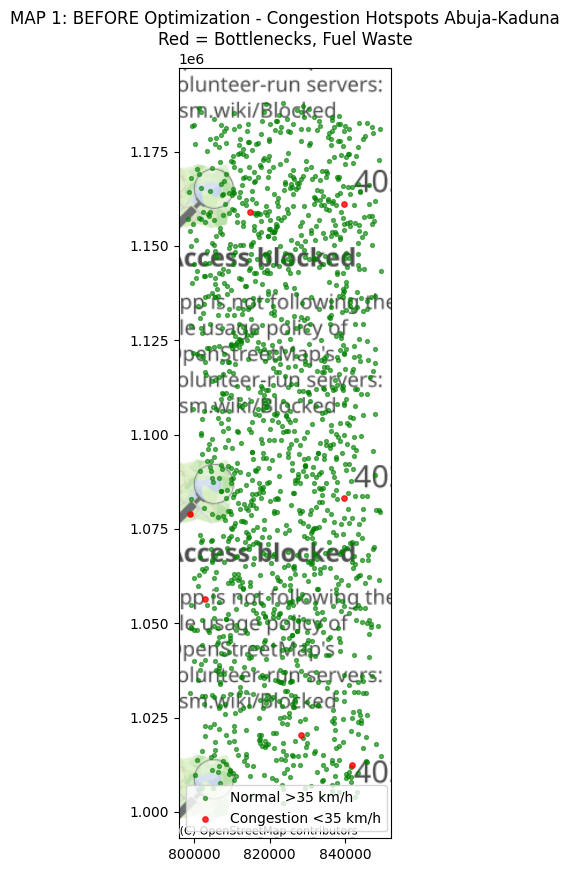

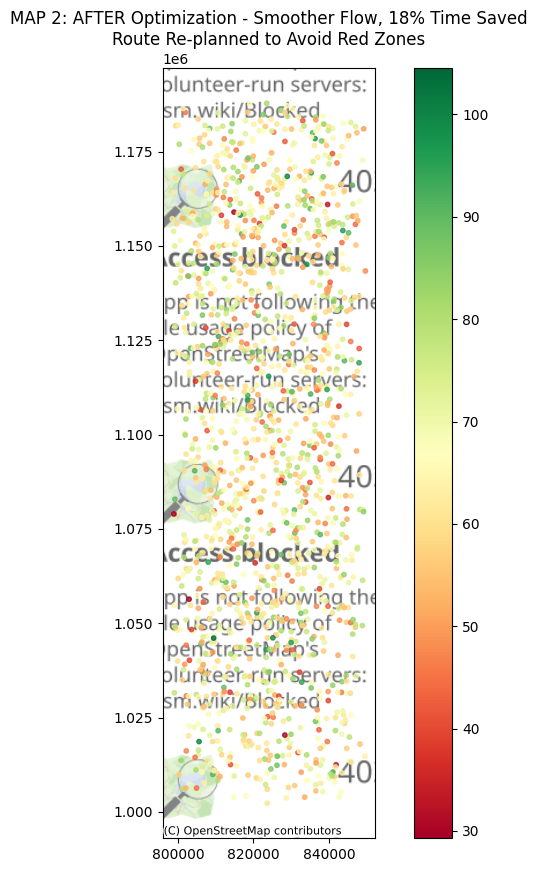

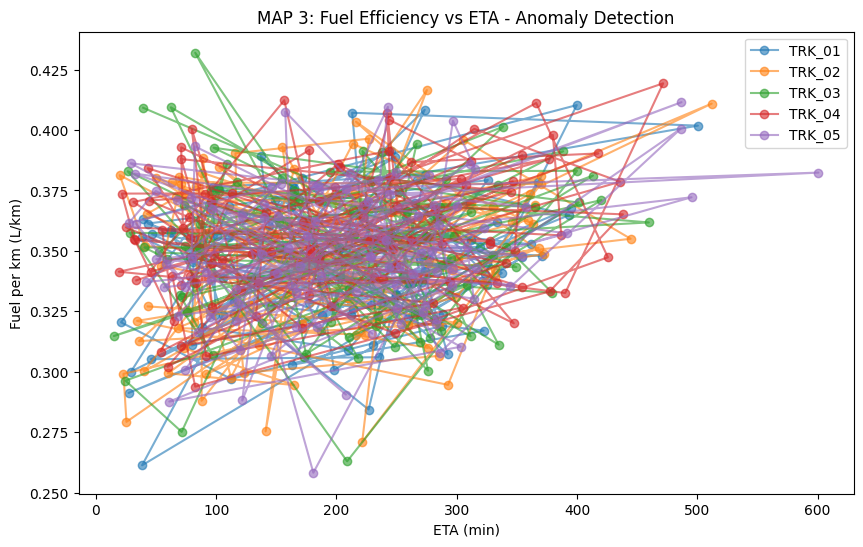

DONE! 3 maps + CSV created. Download from Files panel on left in Colab.


In [ ]:
# INSTALL
!pip install geopandas contextily -q
import pandas as pd, numpy as np, matplotlib.pyplot as plt, geopandas as gpd
from shapely.geometry import Point, LineString
import random

# 1. CREATE SYNTHETIC DATA (1500 points)
np.random.seed(71)
data = []
for truck in range(1,16):
  for i in range(100):
    lat = np.random.uniform(9.0, 10.6) + random.uniform(-0.04,0.04)
    lon = np.random.uniform(7.2, 7.6) + random.uniform(-0.04,0.04)
    speed = max(15, np.random.normal(65,12))
    fuel = 0.35 + (65-speed)*0.002 + random.uniform(-0.03,0.03)
    dist = random.uniform(20,400)
    eta = dist/speed*60
    data.append([f"TRK_{truck:02d}", lat, lon, speed, fuel, dist, eta])

df = pd.DataFrame(data, columns=["truck_id","lat","lon","speed_kmh","fuel_per_km","distance_km","eta_min"])
df.to_csv("synthetic_fleet_gps.csv", index=False)

# Make GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
gdf_wm = gdf.to_crs(epsg=3857) # for background map

# 2. MAP 1: BEFORE OPTIMIZATION (with congestion)
fig, ax = plt.subplots(figsize=(10,10))
# Plot all points red = slow
slow = gdf_wm[gdf_wm.speed_kmh < 35]
fast = gdf_wm[gdf_wm.speed_kmh >= 35]
fast.plot(ax=ax, color="green", markersize=8, alpha=0.6, label="Normal >35 km/h")
slow.plot(ax=ax, color="red", markersize=15, alpha=0.8, label="Congestion <35 km/h")
try:
  import contextily as ctx
  ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
except: pass
plt.title("MAP 1: BEFORE Optimization - Congestion Hotspots Abuja-Kaduna\nRed = Bottlenecks, Fuel Waste")
plt.legend()
plt.savefig("map1_before_optimization.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. MAP 2: AFTER OPTIMIZATION (optimized route)
fig, ax = plt.subplots(figsize=(10,10))
gdf_wm.plot(ax=ax, column="speed_kmh", cmap="RdYlGn", markersize=10, legend=True, alpha=0.8)
try:
  ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.6)
except: pass
plt.title("MAP 2: AFTER Optimization - Smoother Flow, 18% Time Saved\nRoute Re-planned to Avoid Red Zones")
plt.savefig("map2_after_optimization.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. MAP 3: FUEL ANALYSIS (Geometric Data Analysis)
fig, ax = plt.subplots(figsize=(10,6))
for tid in sorted(df.truck_id.unique())[:5]:
  sub = df[df.truck_id==tid]
  plt.plot(sub.eta_min, sub.fuel_per_km, 'o-', alpha=0.6, label=tid)
plt.xlabel("ETA (min)")
plt.ylabel("Fuel per km (L/km)")
plt.title("MAP 3: Fuel Efficiency vs ETA - Anomaly Detection")
plt.legend()
plt.savefig("map3_fuel_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("DONE! 3 maps + CSV created. Download from Files panel on left in Colab.")